# Model Training — Fussball Vorhersagen
Ein Modell für alle Spiele. is_promoted als Feature drin.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle

print('Libraries geladen!')

Libraries geladen!


## 1. Features laden

In [3]:
df = pd.read_csv('data/features.csv', encoding='utf-8')
print(f'Spiele geladen: {len(df)}')
print(f'Saisons: {df["season"].unique()}')
print(f'Aufsteiger Heimteam: {df["is_promoted_home"].sum()}')
print(f'Aufsteiger Auswärtsteam: {df["is_promoted_away"].sum()}')
df.head()

Spiele geladen: 610
Saisons: [2024 2025]
Aufsteiger Heimteam: 9
Aufsteiger Auswärtsteam: 10


,match_id,utc_date,matchday,season_id,season,home_team,away_team,home_form,away_form,home_form_home,away_form_away,heimquote,home_streak,away_streak,home_goal_diff,away_goal_diff,is_promoted_home,is_promoted_away,winner
0,502371,2024-08-23 18:30:00,1,2308,2024,Borussia Mönchengladbach,Bayer 04 Leverkusen,3,11,3,13,0.333333,0,3,-1.0,2.0,0,0,AWAY_TEAM
1,502372,2024-08-24 13:30:00,1,2308,2024,RB Leipzig,VfL Bochum 1848,9,6,11,3,0.666667,0,0,0.8,-1.4,0,0,HOME_TEAM
2,502374,2024-08-24 13:30:00,1,2308,2024,TSG 1899 Hoffenheim,Holstein Kiel,10,0,10,0,0.416667,2,0,1.6,0.0,0,1,HOME_TEAM
3,502375,2024-08-24 13:30:00,1,2308,2024,SC Freiburg,VfB Stuttgart,3,10,2,10,0.166667,0,3,-0.4,1.2,0,0,HOME_TEAM
4,502376,2024-08-24 13:30:00,1,2308,2024,FC Augsburg,SV Werder Bremen,0,11,7,5,0.333333,0,1,-2.2,1.4,0,0,DRAW


## 2. Daten vorbereiten

In [4]:
FEATURES = [
    'home_form', 'away_form',
    'home_form_home', 'away_form_away',
    'heimquote', 'home_streak', 'away_streak',
    'home_goal_diff', 'away_goal_diff',
    'is_promoted_home', 'is_promoted_away'
]
TARGET = 'winner'

df = df.dropna(subset=FEATURES + [TARGET])
print(f'Spiele nach Bereinigung: {len(df)}')

label_map = {'HOME_TEAM': 1, 'DRAW': 0, 'AWAY_TEAM': -1}
df['target'] = df[TARGET].map(label_map)

print('\nErgebnis-Verteilung:')
print(df['winner'].value_counts())

Spiele nach Bereinigung: 610

Ergebnis-Verteilung:
winner
HOME_TEAM    252
AWAY_TEAM    207
DRAW         151
Name: count, dtype: int64


## 3. Train/Test Split — zeitlich

In [5]:
# Saison 2024 + erste Hälfte 2025 → Training
train = df[(df['season'] == 2024) |
           ((df['season'] == 2025) & (df['matchday'] <= 17))]

# Zweite Hälfte 2025 → Test
test = df[(df['season'] == 2025) & (df['matchday'] > 17)]

X_train = train[FEATURES]
y_train = train['target']
X_test  = test[FEATURES]
y_test  = test['target']

print(f'Training: {len(train)} Spiele')
print(f'Test:     {len(test)} Spiele')

Training: 457 Spiele
Test:     153 Spiele


## 4. Baseline

In [6]:
baseline_acc = accuracy_score(y_test, [1] * len(y_test))
print(f'Baseline (immer Heimsieg): {baseline_acc*100:.1f}%')
print('Das ist unsere Messlatte!')

Baseline (immer Heimsieg): 42.5%
Das ist unsere Messlatte!


## 5. Logistische Regression

In [7]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc  = accuracy_score(y_test, lr_pred)

print(f'Logistische Regression: {lr_acc*100:.1f}%')
print()
print(classification_report(y_test, lr_pred,
      target_names=['Auswärtssieg', 'Unentschieden', 'Heimsieg'],
      zero_division=0))

Logistische Regression: 51.0%

               precision    recall  f1-score   support

 Auswärtssieg       0.47      0.54      0.50        48
Unentschieden       0.25      0.03      0.05        40
     Heimsieg       0.54      0.78      0.64        65

     accuracy                           0.51       153
    macro avg       0.42      0.45      0.40       153
 weighted avg       0.44      0.51      0.44       153



## 6. Random Forest

In [8]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)

print(f'Random Forest: {rf_acc*100:.1f}%')
print()
print(classification_report(y_test, rf_pred,
      target_names=['Auswärtssieg', 'Unentschieden', 'Heimsieg'],
      zero_division=0))

Random Forest: 47.7%

               precision    recall  f1-score   support

 Auswärtssieg       0.42      0.48      0.45        48
Unentschieden       0.44      0.17      0.25        40
     Heimsieg       0.52      0.66      0.59        65

     accuracy                           0.48       153
    macro avg       0.46      0.44      0.43       153
 weighted avg       0.47      0.48      0.45       153



## 7. Vergleich

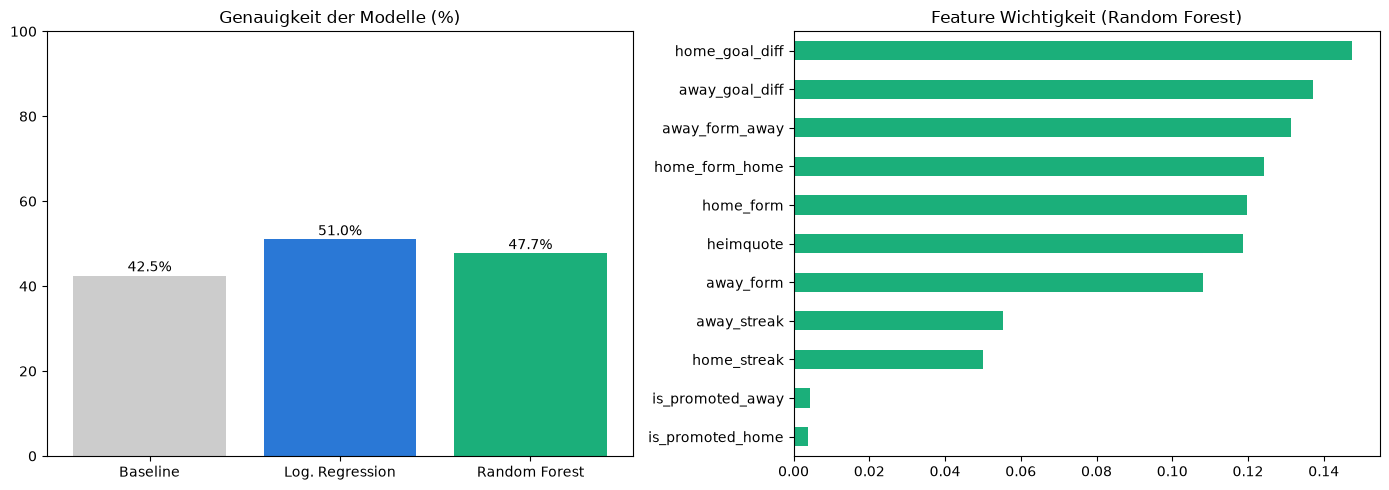

Bestes Modell: Log. Regression mit 51.0%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

modelle = ['Baseline', 'Log. Regression', 'Random Forest']
werte   = [baseline_acc, lr_acc, rf_acc]
farben  = ['#cccccc', '#2a78d6', '#1baf7a']

axes[0].bar(modelle, [v*100 for v in werte], color=farben)
axes[0].set_title('Genauigkeit der Modelle (%)')
axes[0].set_ylim(0, 100)
for i, v in enumerate(werte):
    axes[0].text(i, v*100 + 1, f'{v*100:.1f}%', ha='center')

importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
importances.plot(kind='barh', ax=axes[1], color='#1baf7a')
axes[1].set_title('Feature Wichtigkeit (Random Forest)')

plt.tight_layout()
plt.show()

print(f'Bestes Modell: {modelle[werte.index(max(werte))]} mit {max(werte)*100:.1f}%')

## 8. Confusion Matrix

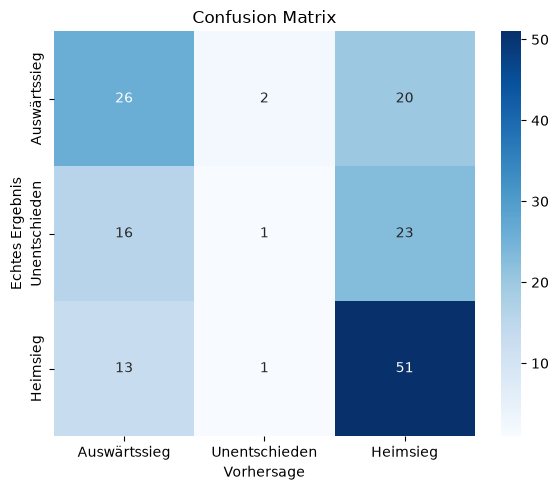

In [10]:
best_pred = rf_pred if rf_acc > lr_acc else lr_pred
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Auswärtssieg', 'Unentschieden', 'Heimsieg'],
            yticklabels=['Auswärtssieg', 'Unentschieden', 'Heimsieg'])
plt.title('Confusion Matrix')
plt.ylabel('Echtes Ergebnis')
plt.xlabel('Vorhersage')
plt.tight_layout()
plt.show()

## 9. Modell speichern

In [ ]:
best_model = rf if rf_acc > lr_acc else lr
model_name = 'Random Forest' if rf_acc > lr_acc else 'Logistische Regression'

model_data = {
    'model':    best_model,
    'features': FEATURES
}

with open('data/model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print(f'Modell gespeichert: {model_name}')
print(f'Genauigkeit: {max(lr_acc, rf_acc)*100:.1f}%')
print('Datei: data/model.pkl')

Modell gespeichert: Logistische Regression
Genauigkeit: 51.0%
Datei: data/model.pkl


## 10. Manuelle Vorhersage testen

In [13]:
label_map_reverse = {1: 'Heimsieg', 0: 'Unentschieden', -1: 'Auswärtssieg'}

beispiel = pd.DataFrame([{
    'home_form':        12,
    'away_form':        6,
    'home_form_home':   10,
    'away_form_away':   4,
    'heimquote':        0.7,
    'home_streak':      3,
    'away_streak':      0,
    'home_goal_diff':   1.5,
    'away_goal_diff':  -0.5,
    'is_promoted_home': 0,
    'is_promoted_away': 0
}])

vorhersage           = best_model.predict(beispiel)[0]
wahrscheinlichkeiten = best_model.predict_proba(beispiel)[0]

print('Bayern (Heim) vs Dortmund (Auswärts):')
print(f'Vorhersage: {label_map_reverse[vorhersage]}')
print()
print('Wahrscheinlichkeiten:')
for klasse, prob in zip(best_model.classes_, wahrscheinlichkeiten):
    print(f'  {label_map_reverse[klasse]}: {prob*100:.1f}%')

Bayern (Heim) vs Dortmund (Auswärts):
Vorhersage: Heimsieg

Wahrscheinlichkeiten:
  Auswärtssieg: 8.9%
  Unentschieden: 19.3%
  Heimsieg: 71.8%
